In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score
from pathlib import Path

# Define files to analyze
FILES_TO_ANALYZE = [
    "outputs/ECT/Llama-3.1-8B-Instruct_TriviaMC_ect_results.json",
    "outputs/ECT/Llama-3.1-8B_TriviaMC_ect_results.json",
    "outputs/ECT/Llama-3.1-8B_fs-balanced_TriviaMC_ect_results.json",
    "outputs/ECT/Llama-3.1-8B_fs-random_ZVU_TriviaMC_ect_results.json",
    "outputs/ECT/Llama-3.1-8B_fs-all_answers_Z_TriviaMC_ect_results.json",
    "outputs/ECT/Llama-3.1-8B_fs-none_TriviaMC_ect_results.json",
    "outputs/ECT/Llama-3.1-8B_fs-deceptive_examples_TriviaMC_ect_results.json",
    "outputs/ECT/Llama-3.1-8B-Instruct_adapter-ect_20251222_215412_v0uei7y1_2000_TriviaMC_ect_results.json",
]

In [ ]:
def compute_entropy(probs):
    """Compute entropy from probability distribution."""
    probs = np.array(probs)
    # Avoid log(0)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def analyze_file(filepath):
    """Analyze a single ECT results file."""
    with open(filepath, 'r') as f:
        data = json.load(f)

    summary = data.get('summary', {})

    # Extract data for each question
    stated_confidences = []
    mc_entropies = []
    mc_answers = []
    confidence_answers = []
    is_correct = []

    for item in data['data']:
        # Get stated confidence value
        stated_confidences.append(item['stated_confidence_value'])

        # Compute entropy from MC probs
        mc_entropy = compute_entropy(item['mc_probs'])
        mc_entropies.append(mc_entropy)

        # Get MC answer (predicted_answer)
        mc_answers.append(item['predicted_answer'])

        # Get confidence answer (stated_confidence_response)
        confidence_answers.append(item['stated_confidence_response'])

        # Correctness label
        is_correct.append(int(item['is_correct']))

    # Invert entropy (low entropy = high confidence)
    inverted_entropies = [-e for e in mc_entropies]

    # Compute correlation between entropy and stated confidence
    pearson_r, pearson_p = pearsonr(stated_confidences, inverted_entropies)
    spearman_r, spearman_p = spearmanr(stated_confidences, inverted_entropies)

    # Calibration / discrimination metrics from summary (computed at run time
    # using whatever S-Z -> probability mapping run_ect.py applied).
    stated_auroc = summary.get('auroc')
    ece = summary.get('ece')
    brier = summary.get('brier_score')
    accuracy = summary.get('overall_accuracy')
    mean_stated_conf = summary.get('mean_stated_confidence')

    # AUROC ceiling: how well does the model's MC entropy itself predict correctness?
    # Stated-confidence AUROC cannot exceed this. Comparing the two separates
    # "introspective access" (closing the gap) from "underlying calibration" (raising the ceiling).
    is_correct_arr = np.array(is_correct)
    if len(np.unique(is_correct_arr)) == 2:
        entropy_auroc = roc_auc_score(is_correct_arr, np.array(inverted_entropies))
    else:
        entropy_auroc = float('nan')

    return {
        'stated_confidences': stated_confidences,
        'mc_entropies': mc_entropies,
        'inverted_entropies': inverted_entropies,
        'mc_answers': mc_answers,
        'confidence_answers': confidence_answers,
        'is_correct': is_correct,
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
        'stated_auroc': stated_auroc,
        'entropy_auroc': entropy_auroc,
        'ece': ece,
        'brier': brier,
        'accuracy': accuracy,
        'mean_stated_conf': mean_stated_conf,
        'n_questions': len(stated_confidences)
    }

In [ ]:
# Condition descriptions for each file
CONDITION_DESCRIPTIONS = {
    "Llama-3.1-8B-Instruct_TriviaMC_ect_results.json":
        "Instruct model (control). Uses chat template with explicit instructions to report confidence on S-Z scale.",
    "Llama-3.1-8B_TriviaMC_ect_results.json":
        "Base model with 'fixed' few-shot (3 hand-crafted examples: easy/hard/medium). "
        "Best-performing base model condition (ECE=0.076, AUROC=0.706).",
    "Llama-3.1-8B_fs-balanced_TriviaMC_ect_results.json":
        "Base model with 'balanced' few-shot (8 examples, one per confidence level S-Z, shuffled). "
        "Ensures model sees uniform distribution across all confidence levels.",
    "Llama-3.1-8B_fs-random_ZVU_TriviaMC_ect_results.json":
        "Base model with 'random' few-shot (3 stratified examples sampled from finetuned model predictions: "
        "one low, one mid, one high confidence).",
    "Llama-3.1-8B_fs-all_answers_Z_TriviaMC_ect_results.json":
        "Base model with all few-shot examples labeled 'Z' (highest confidence). "
        "Tests anchoring bias: does the model copy the constant label or introspect?",
    "Llama-3.1-8B_fs-none_TriviaMC_ect_results.json":
        "Base model with no few-shot examples (only the S-Z scale definition). "
        "Model collapses to a single confidence level (498/500 = 'V'). Near-random AUROC (0.511).",
    "Llama-3.1-8B_fs-deceptive_examples_TriviaMC_ect_results.json":
        "Base model with 'deceptive' few-shot (3 examples with FLIPPED confidence labels: S<->Z, T<->Y, etc.). "
        "Tests introspection vs. copying. Model maintains positive correlation despite inverted labels.",
    "Llama-3.1-8B-Instruct_adapter-ect_20251222_215412_v0uei7y1_2000_TriviaMC_ect_results.json":
        "Finetuned model (Instruct + LoRA adapter trained for metacognition). "
        "Best overall: Pearson r=0.786, Spearman rho=0.852. Strong evidence finetuning improves introspection.",
}


def _fmt_metric(x, fmt='.3f'):
    if x is None:
        return 'n/a'
    if isinstance(x, float) and np.isnan(x):
        return 'n/a'
    return format(x, fmt)


def plot_analysis(filepath, results):
    """Create a comprehensive plot for a single file's analysis."""
    filename = Path(filepath).name
    description = CONDITION_DESCRIPTIONS.get(filename, "")

    # Create figure with subplots - extra height for description
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(f'ECT Analysis: {filename}', fontsize=14, fontweight='bold', y=0.98)

    # 1. Scatter plot: Stated Confidence vs Inverted Entropy
    ax = axes[0, 0]
    ax.scatter(results['stated_confidences'], results['inverted_entropies'], alpha=0.5)
    ax.set_xlabel('Stated Confidence')
    ax.set_ylabel('Inverted MC Entropy (-H)')
    ax.set_title(
        f"Pearson r={results['pearson_r']:.3f} (p={results['pearson_p']:.2e})  |  "
        f"Spearman ρ={results['spearman_r']:.3f} (p={results['spearman_p']:.2e})\n"
        f"AUROC(stated)={_fmt_metric(results['stated_auroc'])}  |  "
        f"AUROC(-H, ceiling)={_fmt_metric(results['entropy_auroc'])}  |  "
        f"ECE={_fmt_metric(results['ece'])}  |  "
        f"mean conf={_fmt_metric(results['mean_stated_conf'])}"
    )
    ax.grid(True, alpha=0.3)

    # 2. Distribution of MC Answers
    ax = axes[0, 1]
    from collections import Counter
    mc_counts = Counter(results['mc_answers'])
    options = sorted(mc_counts.keys())
    counts = [mc_counts[opt] for opt in options]
    ax.bar(options, counts, color='steelblue', alpha=0.7)
    ax.set_xlabel('MC Answer')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of MC Answers')
    ax.grid(True, alpha=0.3, axis='y')

    # 3. Distribution of Confidence Answers
    ax = axes[1, 0]
    conf_counts = Counter(results['confidence_answers'])
    options = sorted(conf_counts.keys())
    counts = [conf_counts[opt] for opt in options]
    ax.bar(options, counts, color='coral', alpha=0.7)
    ax.set_xlabel('Confidence Answer (S-Z)')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Confidence Answers')
    ax.grid(True, alpha=0.3, axis='y')

    # 4. Histogram of MC Entropy values
    ax = axes[1, 1]
    ax.hist(results['mc_entropies'], bins=30, color='green', alpha=0.6, edgecolor='black')
    ax.set_xlabel('MC Entropy (bits)')
    ax.set_ylabel('Count')
    ax.set_title(f"MC Entropy Distribution\nMean: {np.mean(results['mc_entropies']):.3f}, "
                 f"Std: {np.std(results['mc_entropies']):.3f}")
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout(rect=[0, 0.06, 1, 0.96])

    # Add condition description below the plots
    if description:
        fig.text(0.5, 0.01, description, ha='center', va='bottom',
                 fontsize=10, style='italic', wrap=True,
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

    return fig

In [ ]:
# Analyze all files
all_results = {}

for filepath in FILES_TO_ANALYZE:
    print(f"\nAnalyzing: {Path(filepath).name}")
    try:
        results = analyze_file(filepath)
        all_results[filepath] = results
        print(f"  N questions:               {results['n_questions']}")
        print(f"  Pearson r (H vs conf):     {_fmt_metric(results['pearson_r'])} (p={results['pearson_p']:.2e})")
        print(f"  Spearman ρ (H vs conf):    {_fmt_metric(results['spearman_r'])} (p={results['spearman_p']:.2e})")
        print(f"  AUROC (stated conf):       {_fmt_metric(results['stated_auroc'])}")
        print(f"  AUROC (-entropy, ceiling): {_fmt_metric(results['entropy_auroc'])}")
        print(f"  ECE:                       {_fmt_metric(results['ece'])}")
        print(f"  Brier score:               {_fmt_metric(results['brier'])}")
        print(f"  Accuracy:                  {_fmt_metric(results['accuracy'])}")
        print(f"  Mean stated confidence:    {_fmt_metric(results['mean_stated_conf'])}")
        print(f"  Mean MC entropy:           {np.mean(results['mc_entropies']):.3f}")
    except Exception as e:
        print(f"  Error: {e}")


Creating plot for: Llama-3.1-8B-Instruct_TriviaMC_ect_results.json


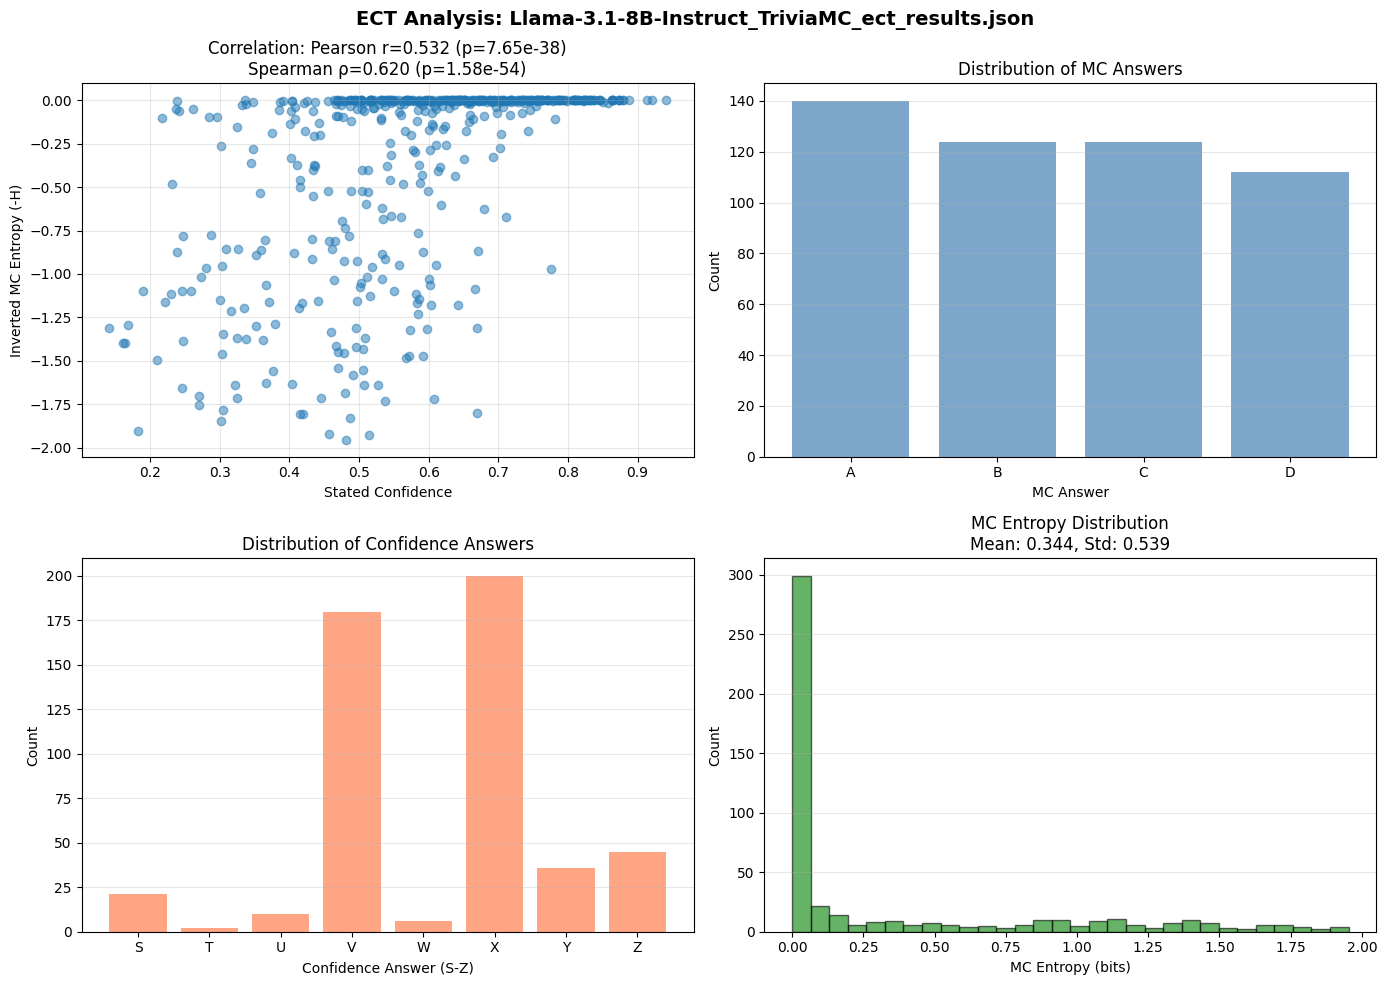


Creating plot for: Llama-3.1-8B_TriviaMC_ect_results.json


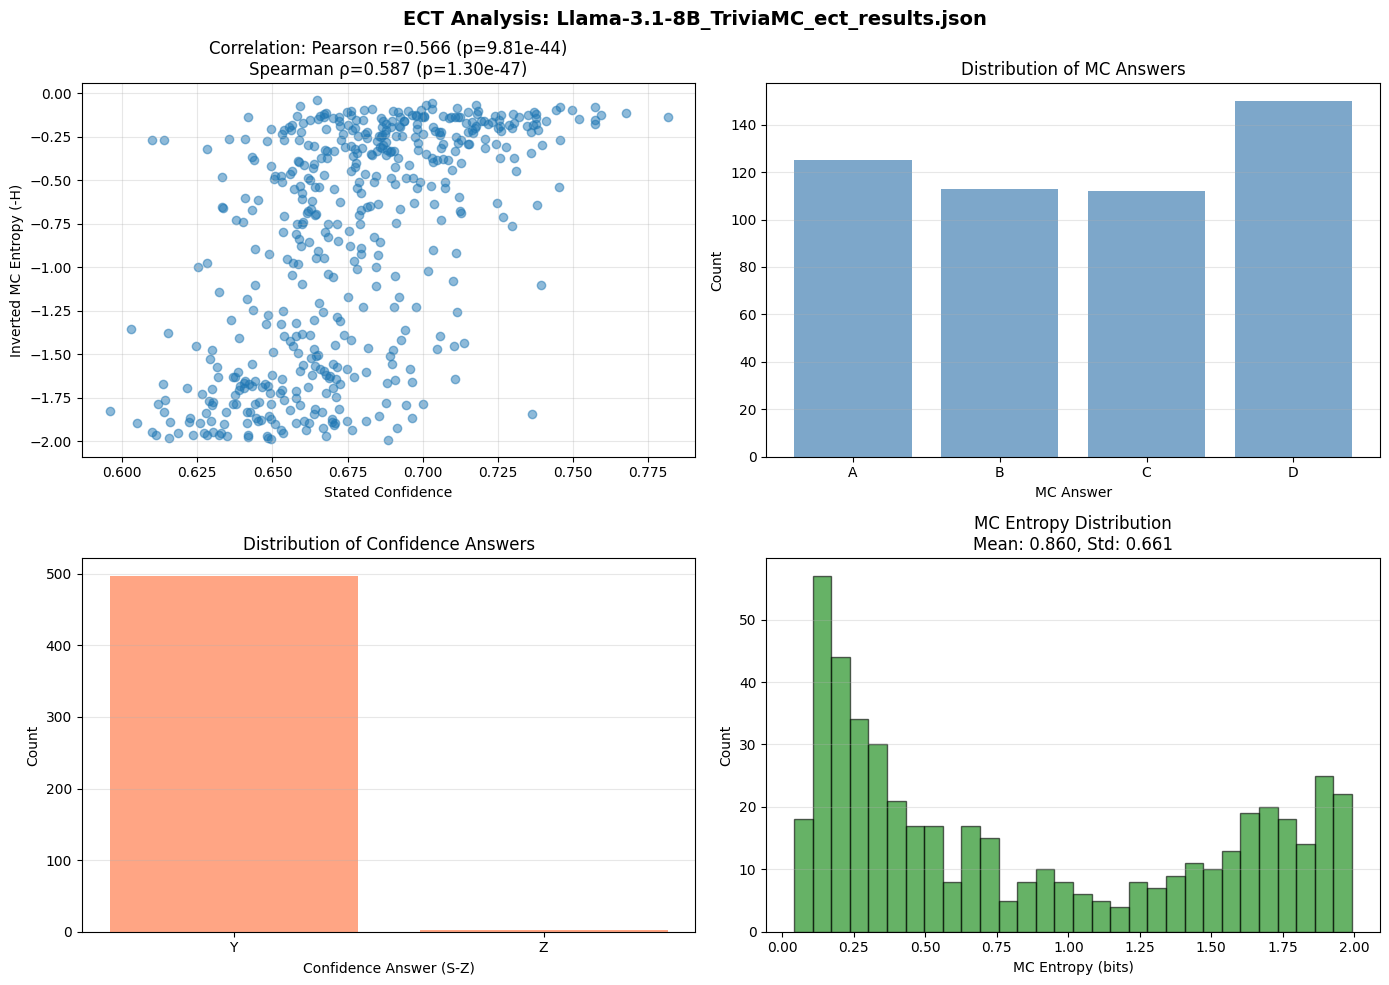


Creating plot for: Llama-3.1-8B_fs-balanced_TriviaMC_ect_results.json


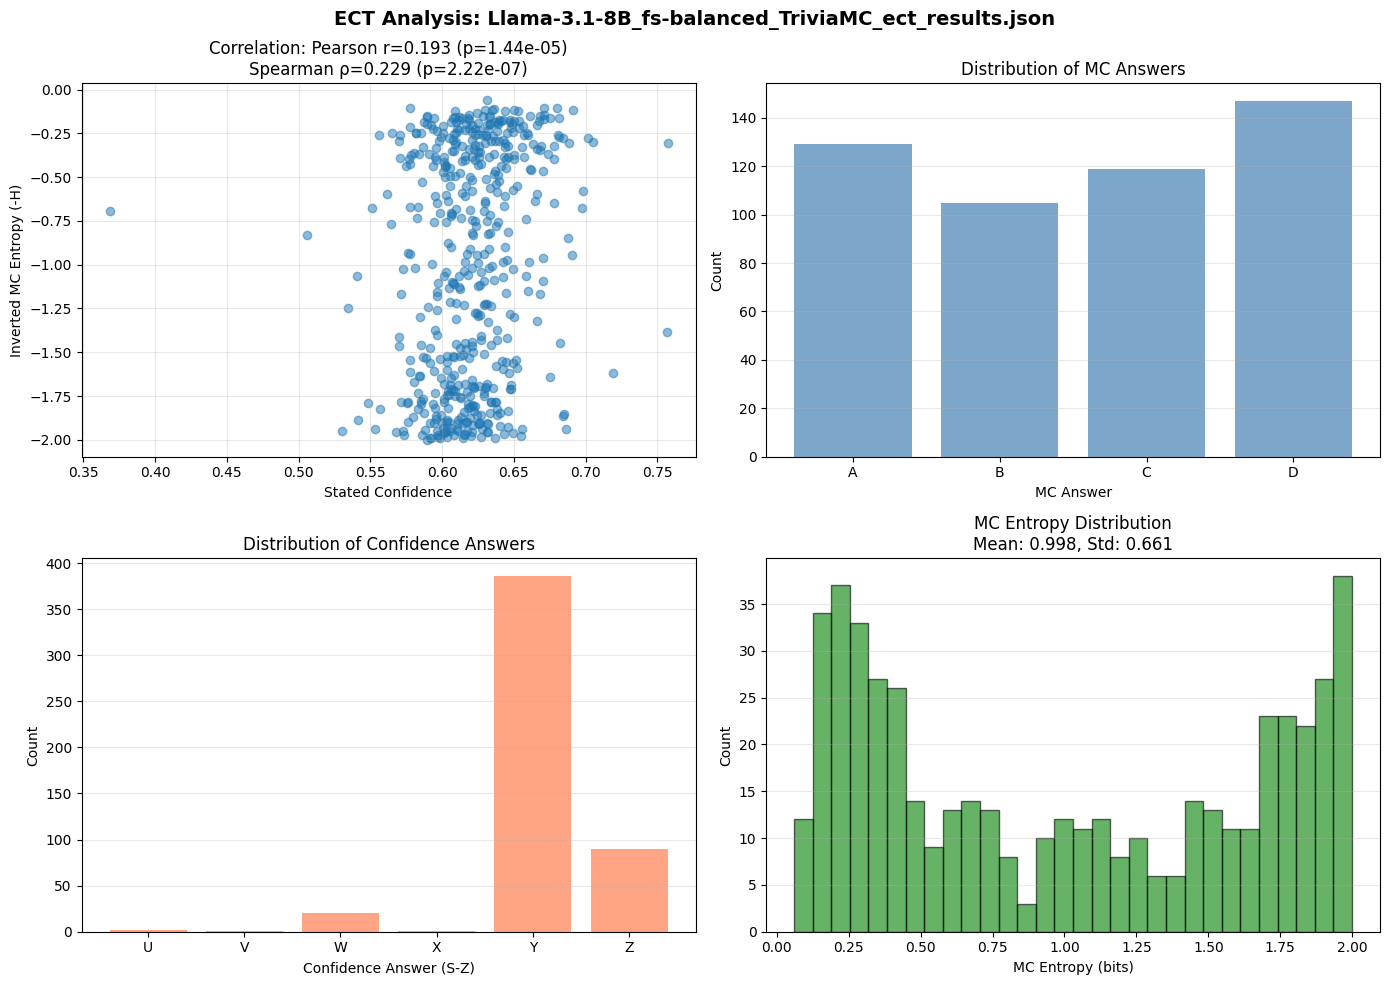


Creating plot for: Llama-3.1-8B_fs-random_ZVU_TriviaMC_ect_results.json


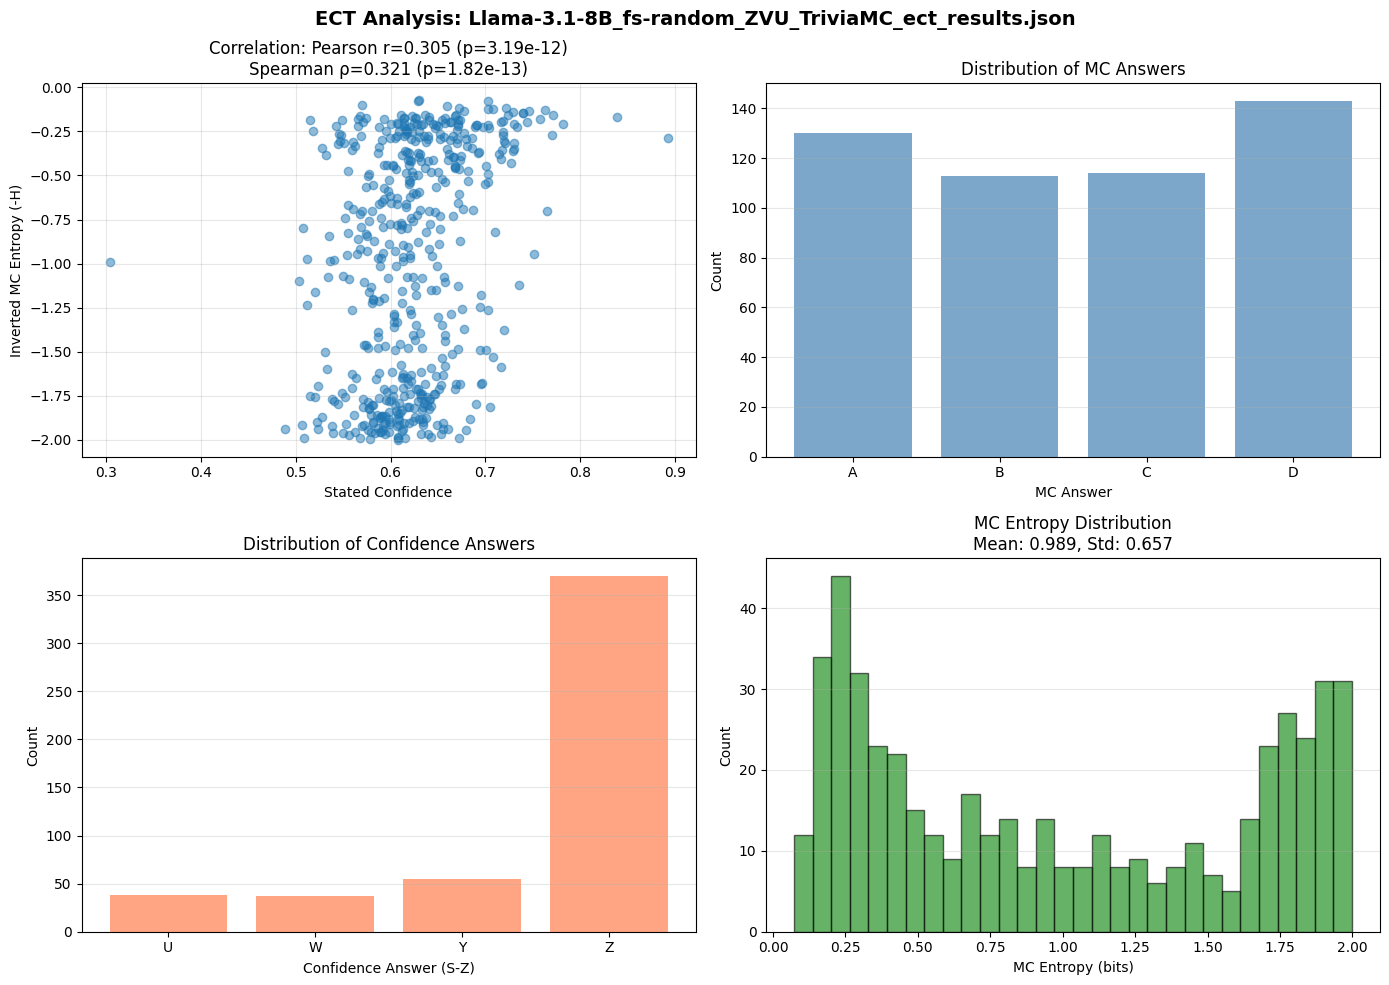


Creating plot for: Llama-3.1-8B_fs-all_answers_Z_TriviaMC_ect_results.json


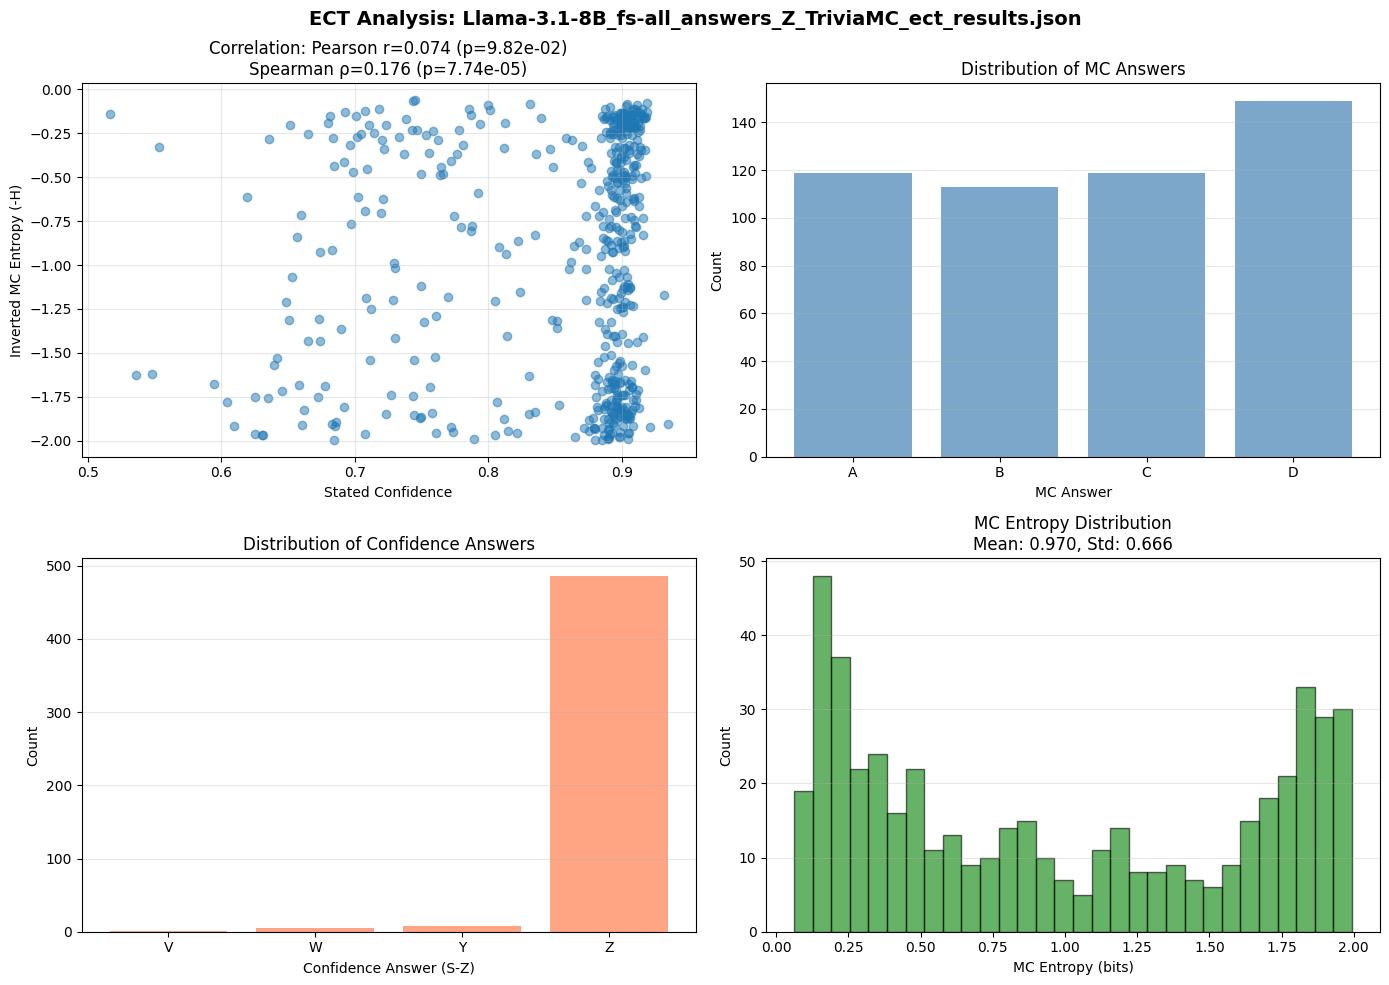


Creating plot for: Llama-3.1-8B_fs-none_TriviaMC_ect_results.json


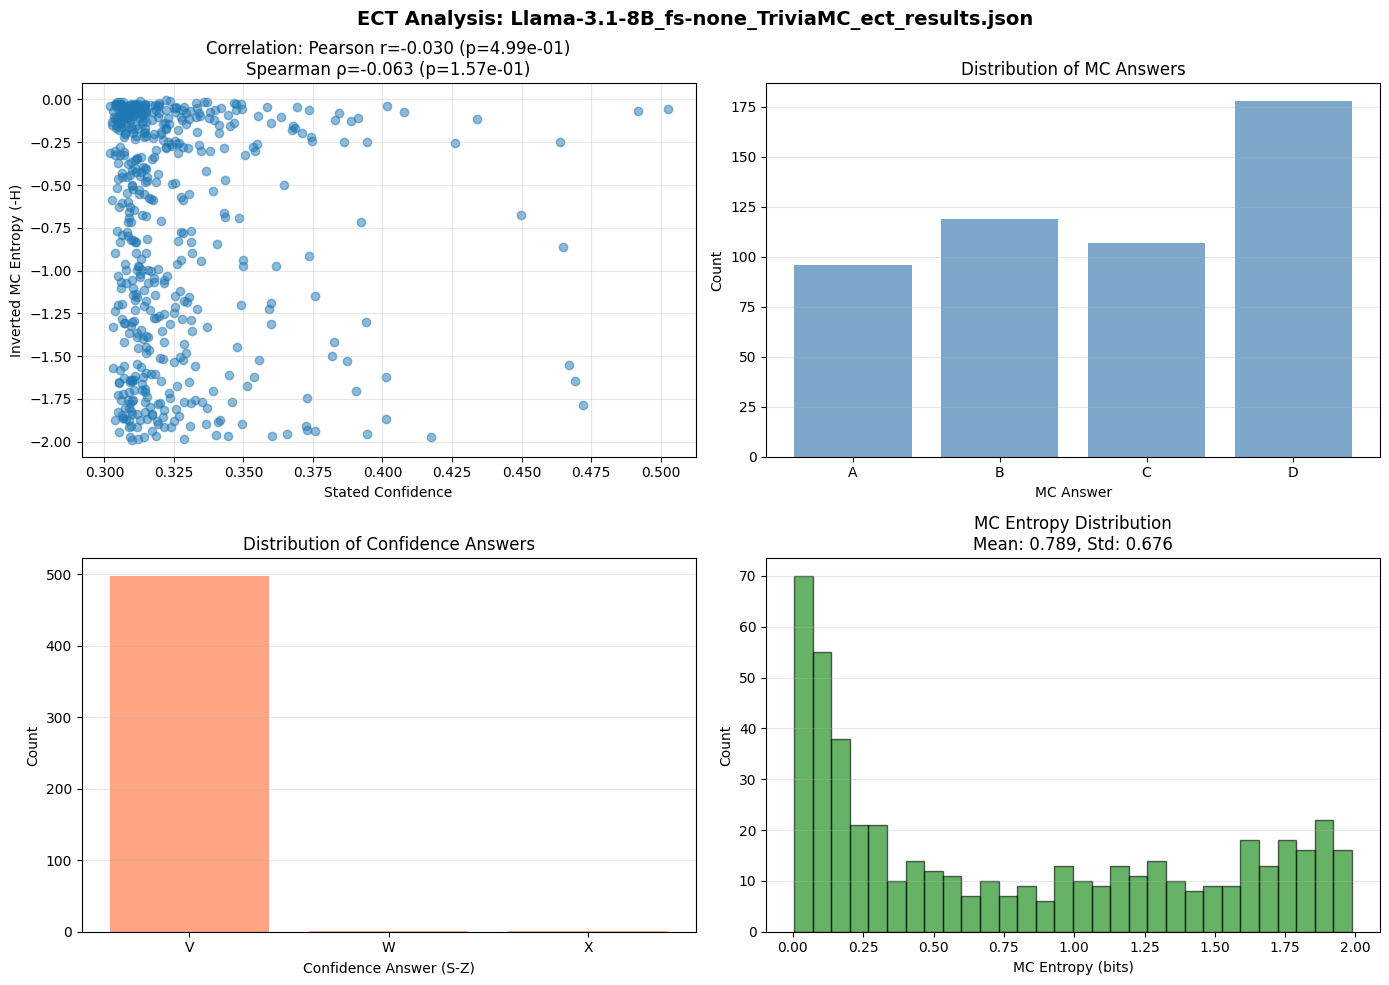


Creating plot for: Llama-3.1-8B_fs-deceptive_examples_TriviaMC_ect_results.json


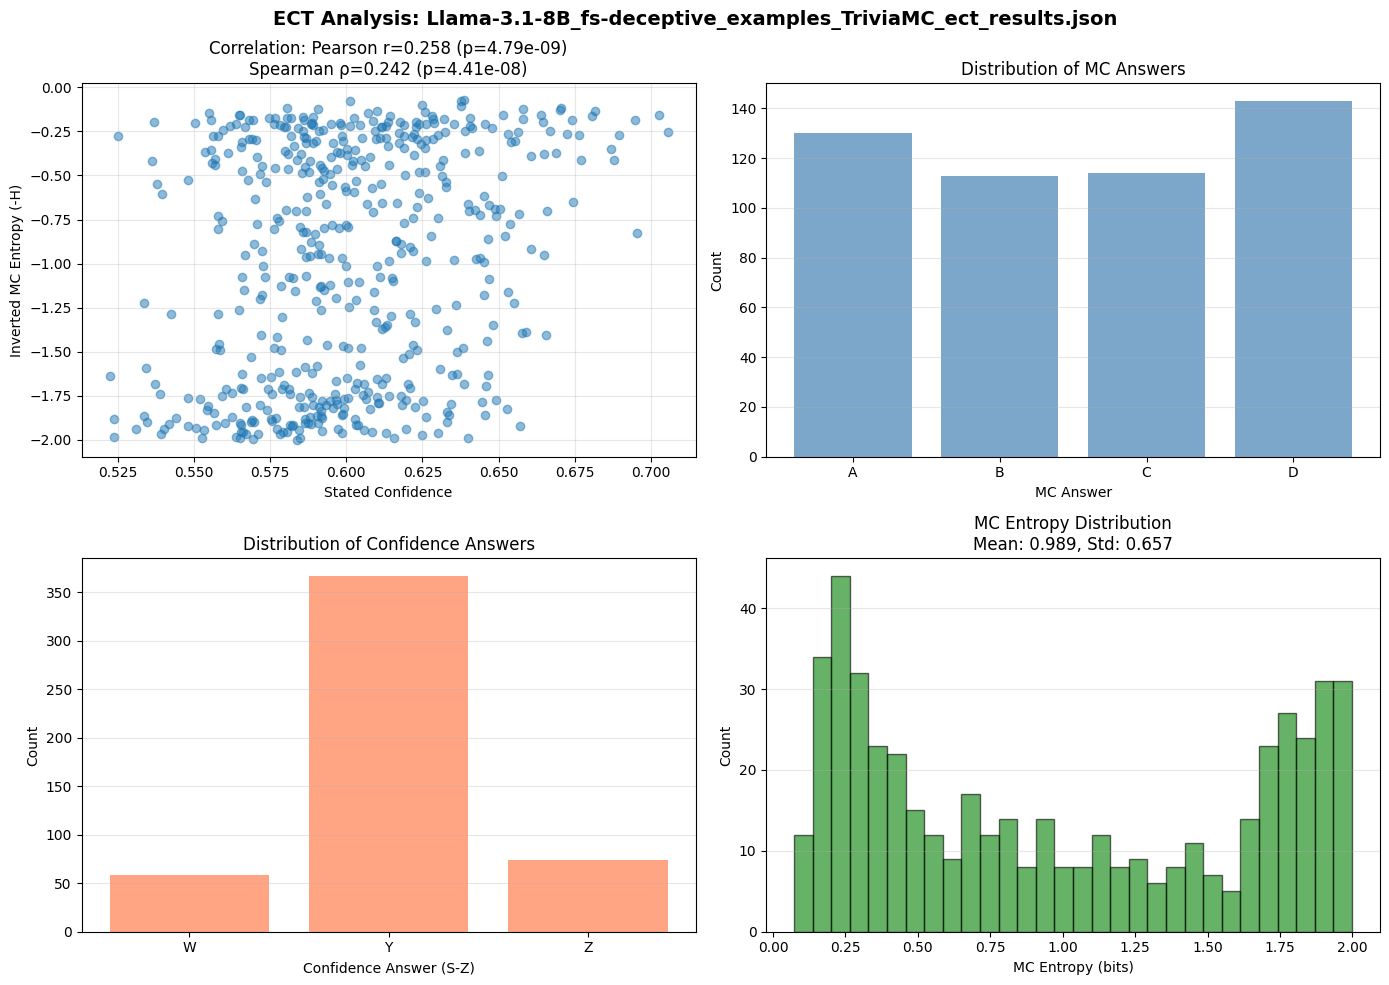


Creating plot for: Llama-3.1-8B-Instruct_adapter-ect_20251222_215412_v0uei7y1_2000_TriviaMC_ect_results.json


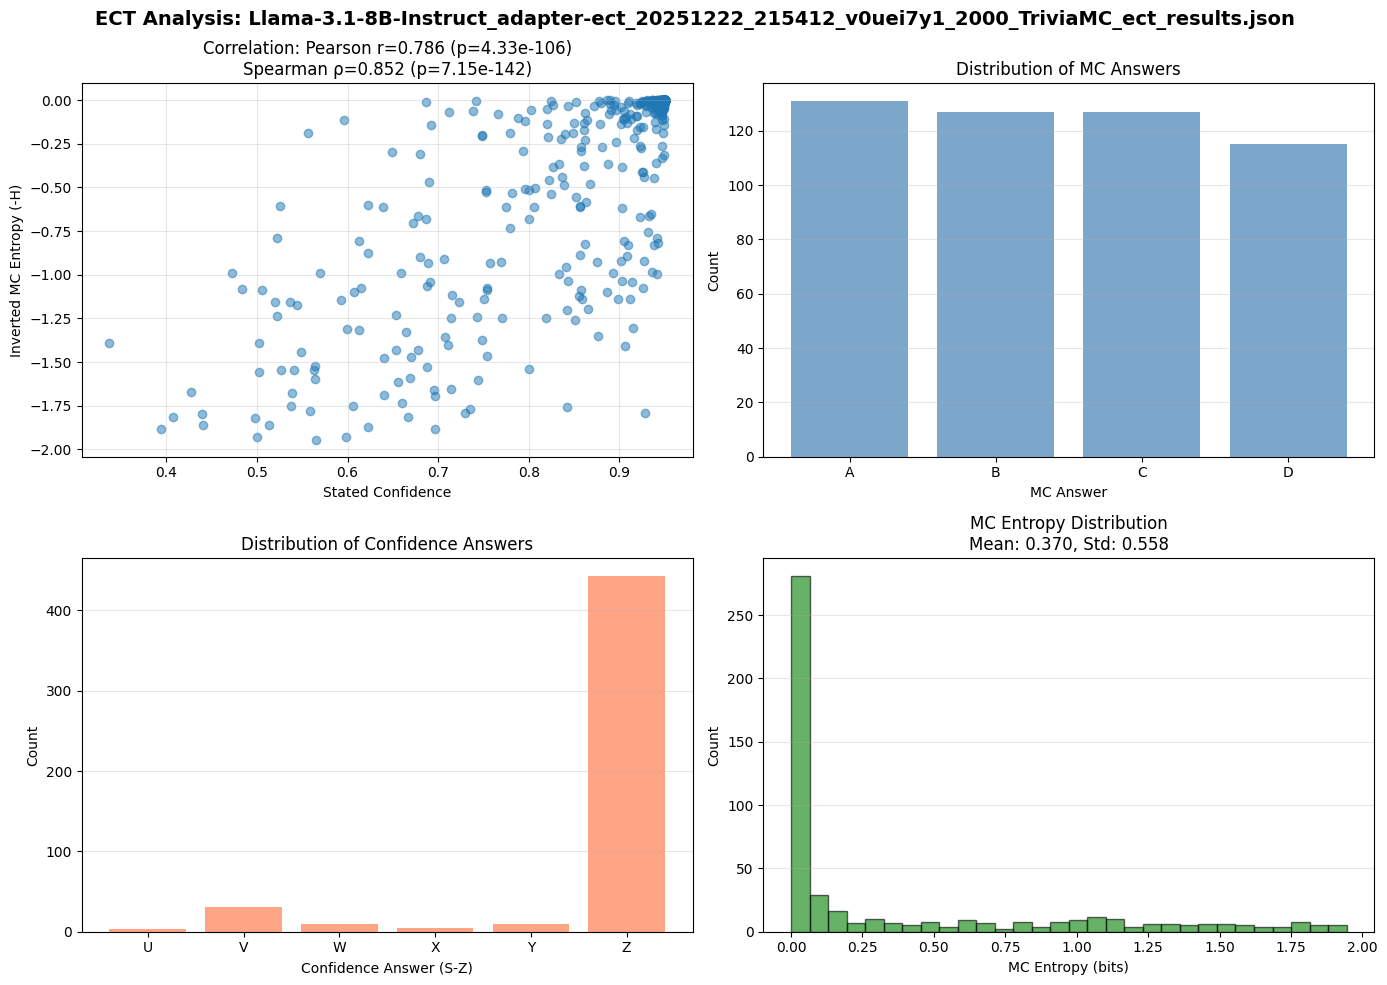

In [5]:
# Create plots for each file
for filepath, results in all_results.items():
    print(f"\nCreating plot for: {Path(filepath).name}")
    fig = plot_analysis(filepath, results)
    plt.show()

In [ ]:
# Summary comparison across all files
print("\n" + "="*140)
print("SUMMARY COMPARISON")
print("="*140)
print("Pearson r / Spearman ρ : entropy <-> stated confidence (introspective access)")
print("AUROC(stated)          : stated confidence as a discriminator of correct/incorrect")
print("AUROC(-H)              : MC entropy as a discriminator (ceiling stated AUROC can approach)")
print("ECE                    : calibration error of stated confidence vs. accuracy")
print("mean conf              : mean stated confidence (watch this alongside AUROC/ECE to detect inflation)")

summary_data = []
for filepath, results in all_results.items():
    filename = Path(filepath).name
    summary_data.append({
        'file': filename,
        'n': results['n_questions'],
        'pearson_r': results['pearson_r'],
        'spearman_r': results['spearman_r'],
        'stated_auroc': results['stated_auroc'],
        'entropy_auroc': results['entropy_auroc'],
        'ece': results['ece'],
        'accuracy': results['accuracy'],
        'mean_stated_conf': results['mean_stated_conf'],
        'mean_entropy': float(np.mean(results['mc_entropies'])),
    })

# Sort by Pearson correlation
summary_data.sort(key=lambda x: x['pearson_r'], reverse=True)

header = (f"\n{'File':<70} {'N':>4} {'Pear r':>7} {'Spear ρ':>8} "
          f"{'AUROC':>6} {'AUROC':>6} {'ECE':>6} {'Acc':>6} {'mConf':>6} {'mH':>6}")
subheader = (f"{'':<70} {'':>4} {'':>7} {'':>8} "
             f"{'stat':>6} {'(-H)':>6} {'':>6} {'':>6} {'':>6} {'':>6}")
print(header)
print(subheader)
print("-"*140)
for item in summary_data:
    print(
        f"{item['file']:<70} {item['n']:>4} "
        f"{item['pearson_r']:>7.3f} {item['spearman_r']:>8.3f} "
        f"{_fmt_metric(item['stated_auroc']):>6} {_fmt_metric(item['entropy_auroc']):>6} "
        f"{_fmt_metric(item['ece']):>6} {_fmt_metric(item['accuracy']):>6} "
        f"{_fmt_metric(item['mean_stated_conf']):>6} {item['mean_entropy']:>6.3f}"
    )